<a href="https://colab.research.google.com/github/joseferbis-cell/PLs-ADFM/blob/main/practice_2_a_parameterized_nns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Datos en Física Moderna

(C)2025 Pietro Vischia, vischia@uniovi.es

## PL 2: machine learning paramétrico

In this practice, you'll implement the parameterized machine learning algorithm devised by Baldi et al., [1601.07913](https://arxiv.org/abs/1601.07913)

In [ ]:
# Uncomment and run this if you are running on Colab (remove only the "#", keep the "!").
# You can run it anyway, but it will do nothing if you have already installed all dependencies
# (and it will take some time to tell you it is not gonna do anything)


from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/"
! git clone https://github.com/vischia/atdtf.git
%cd atdtf
!pwd
!ls
!pip install livelossplot shap

Mounted at /content/drive
/content/drive/MyDrive
fatal: destination path 'atdtf' already exists and is not an empty directory.
/content/drive/MyDrive/atdtf
/content/drive/MyDrive/atdtf
data			data_for_practica2.zip.1  figs
databases		data_for_practica2.zip.2  PL1_sesgo_inductivo.ipynb
data_for_practica2	data_for_practica2.zip.3  PL2_parameterized_nns.ipynb
data_for_practica2.zip	data_for_practica2.zip.4  README.md


In [ ]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import glob
import os
import re
import math
import socket
import json
import pickle
import gzip
import copy
import array
import numpy as np
import numpy.lib.recfunctions as recfunc

from scipy.optimize import newton
from scipy.stats import norm

import datetime
from timeit import default_timer as timer

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.tree import export_graphviz
from sklearn.inspection import permutation_importance
try:
    # See #1137: this allows compatibility for scikit-learn >= 0.24
    from sklearn.utils import safe_indexing
except ImportError:
    from sklearn.utils import _safe_indexing

from livelossplot import PlotLossesKeras

import torch

import pandas as pd


In [ ]:
INPUT_FOLDER = './'
HAVE_GPU = True


We will use the [HEP-mass dataset](http://archive.ics.uci.edu/ml/datasets/hepmass) hosted by UCIrvine together with many other datasets used to test machine learning applications.

This dataset provides top pair production events as a background, and the classification task is to separate them from events generated by a high-mass resonance (masses of 500--1000 GeV). The larger the mass, the easiest the prediction task.

The label is 1 for signal, and 0 for background. There are 27 normalized features, divided into 22 low-level ones and 5 high-level ones. Because of time constraints, we won't explore the topic of pitting low-level and high-level features against each other or of mixing them, but you are encouraged to play with them later.

<img src="https://github.com/vischia/adfm_2024-2025/blob/master/figs/hepmass.png?raw=1" alt="masses from 1601.07913" style="width:50%;"/>

(figure from [1601.07913](https://arxiv.org/abs/1601.07913))

You can download the data from:

[https://www.hep.uniovi.es/vischia/adfm/](https://www.hep.uniovi.es/vischia/adfm/)

by hand or by running:

In [ ]:
downloadMinidata=True

if downloadMinidata:
    !mkdir data
    !cd data
    !wget https://www.hep.uniovi.es/vischia/adfm/data_for_practica2.zip
    !unzip data_for_practica2.zip
    !cd ..

mkdir: cannot create directory ‘data’: File exists
--2025-11-13 14:28:17--  https://www.hep.uniovi.es/vischia/adfm/data_for_practica2.zip
Resolving www.hep.uniovi.es (www.hep.uniovi.es)... 156.35.212.25
Connecting to www.hep.uniovi.es (www.hep.uniovi.es)|156.35.212.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57367876 (55M) [application/zip]
Saving to: ‘data_for_practica2.zip.5’

data_for_practica2. 100%[===================>]  54.71M  33.1MB/s    in 1.7s    

2025-11-13 14:28:19 (33.1 MB/s) - ‘data_for_practica2.zip.5’ saved [57367876/57367876]

Archive:  data_for_practica2.zip
replace data_for_practica2/not1000_750_test_small.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data_for_practica2/not1000_750_test_small.csv  
  inflating: data_for_practica2/not1000_750_train_small.csv  
  inflating: data_for_practica2/not1000_750_test_large.csv  
  inflating: data_for_practica2/not1000_750_train_large.csv  
  inflating: data_for_practica2/1000_train

In [ ]:
# Do not set these to True in the live tutorial,
# otherwise you will clog the conference venue connection for nothing.
# The skimmed files are already included in this repository

createLowMass=False
createHighMass=False

if createLowMass:
    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/not1000_train.csv.gz
    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/not1000_test.csv.gz
    cols=["label", "f0", "f1", "f2", "f3", "f4", "f5", "f6", "f7", "f8", "f9", "f10", "f11", "f12", "f13",
          "14f", "15f", "f16", "f17", "f18", "f19", "f20", "f21", "f22", "f23", "f24", "f25", "f26", "mass"]

    train_set = pd.read_csv('./not1000_train.csv.gz', index_col=False, names=cols, header=0)
    test_set = pd.read_csv('./not1000_test.csv.gz', index_col=False, names=cols, header=0)

    # Here we exploit the fact that the background has an assigned random mass sampled from
    # the same set than that of the signal. Therefore we can just require the mass to be 500
    # without having to check for the signal and background label.
    # A final test ensures the amount of events is approximately the same.

    # In the data set, for some reason the "mass 500" is encoded as 499.999969, but "==499.999969" does not
    # match any entry. We will therefore use "<501" to select the events with mass=500

    train_set=train_set[train_set['mass']<501]
    test_set=test_set[test_set['mass']<501]

    print('Full train', len(train_set),
          len(train_set[train_set['label']==1]),
          len(train_set[train_set['label']==0]))
    print('Full test', len(test_set),
          len(test_set[test_set['label']==1]),
          len(test_set[test_set['label']==0]))

    train_set_temp=train_set.head(10000)
    test_set_temp=test_set.head(10000)

    train_set_temp.to_csv('data/not1000_train_medium.csv')
    test_set_temp.to_csv('data/not1000_test_medium.csv')


    train_set_temp=train_set.head(1000)
    test_set_temp=test_set.head(1000)

    train_set_temp.to_csv('data/not1000_train_small.csv')
    test_set_temp.to_csv('data/not1000_test_small.csv')


if createHighMass: # Not needed, I included the small and medium sets in the github repository

    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/1000_train.csv.gz
    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/1000_test.csv.gz
    # This needs to be run only once
    cols=[label_name, "f0", "f1", "f2", "f3", "f4", "f5", "f6", "f7", "f8", "f9", "f10", "f11", "f12", "f13", "14f", "15f", "f16", "f17", "f18", "f19", "f20", "f21", "f22", "f23", "f24", "f25", "f26"]
    train_set = pd.read_csv('./1000_train.csv.gz', index_col=False, names=cols, header=0)
    test_set = pd.read_csv('./1000_test.csv.gz', index_col=False, names=cols, header=0)

    # Randomly pick 10000 events from the full data set
    train_set_temp=train_set.head(10000)
    test_set_temp=test_set.head(10000)

    train_set_temp.to_csv('data/1000_train_medium.csv')
    test_set_temp.to_csv('data/1000_test_medium.csv')

    # Randomly pick 1000 events from the full data set
    train_set_temp=train_set.head(1000)
    test_set_temp=test_set.head(1000)

    train_set_temp.to_csv('data/1000_train_small.csv')
    test_set_temp.to_csv('data/1000_test_small.csv')


In [ ]:
# Load the chosen set
train_set=pd.read_csv('data_for_practica2/not1000_750_train_medium.csv', index_col=False)
test_set=pd.read_csv('data_for_practica2/not1000_750_test_medium.csv', index_col=False)

# Drop mass info, if needed (the "1000..." files don't have a 'mass' column)
if 'mass' in train_set.columns:
    train_set=train_set.drop(['mass'], axis=1)
    test_set=test_set.drop(['mass'], axis=1)
train_set.head()

,Unnamed: 0,label,f0,f1,f2,f3,f4,f5,f6,f7,...,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26
0,1,1.0,-1.401979,-0.942620,1.049402,1.637764,1.681190,-0.005984,0.733926,-0.476641,...,-0.815440,-0.822903,0.156014,-0.197154,1.743123,0.361093,-0.941934,0.026127,1.396366,-0.123928
1,12,0.0,-0.646328,0.132367,0.864149,0.596158,0.266139,-1.054221,-0.801212,0.231854,...,1.226331,-1.368451,-0.189723,-1.710976,-0.573682,-0.800589,-0.594036,-0.377533,-0.113845,-1.300184
2,13,1.0,-0.093261,0.168337,1.287353,0.319592,-1.359426,1.574625,0.988875,-0.268706,...,-0.815440,1.634929,-0.067125,-1.548938,1.743123,-0.015264,-0.080968,0.756942,0.879847,0.218808
3,16,1.0,1.205673,1.103310,-1.132657,-1.284128,-0.823548,0.850488,0.943595,0.516031,...,1.226331,0.383688,-0.162711,1.030514,-0.573682,-0.739276,-0.147738,-0.270474,-0.256237,0.318978
4,19,0.0,-1.134711,1.257473,-0.419845,-0.848054,-1.568315,-1.054221,-0.144344,-0.077036,...,-0.815440,-0.278497,0.340343,0.306618,-0.573682,-0.384413,-0.364842,-0.309805,-0.673690,-0.957803


In [ ]:
print('Training set has', len(train_set), 'entries (', len(train_set[train_set['label']==1]), 'signal entries, ',
      len(train_set[train_set['label']==0]), ' background entries)')

Training set has 10000 entries ( 5002 signal entries,  4998  background entries)


### Split the data set into training and test set

When we train a machine learning algorithm, we are trying to solve an interpolation problem (*find the function of the input features that provides the best approximation of the true function*) by also requiring that the solution generalizes sufficiently well (*the interpolating function must also predict correctly the value of the true function for new, unseen data*).


When we have a labelled dataset, we will therefore split it into: a *training set*, which we will use to train the machine learning algorithm; a *test set*, which we will use to evaluate the performance of the algorithm for various realizations of the algorithm (e.g. tuning hyperparameters); and an *application set*, which are the data we are really interested in studying in the end.

For many applications, when the amount of hyperparameters tuning is moderate, application set and test set can be collapsed into a single set (usually called *test set*). This is what we will do in this tutorial.

![Blah](https://github.com/vischia/adfm_2024-2025/blob/master/figs/trainingNetwork.png?raw=1)

(Image: P. Vischia, [doi:10.5281/zenodo.6373442](https://doi.org/10.5281/zenodo.6373442))

For the data set that we have loaded, we don't need to do any splitting, because the data set is already split.
If our data set needed to be split, we would do something like



In [ ]:
# X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.33, random_state=42)


### Inspect the data set

The first and most important thing to do, when developing a ML application, is to inspect the data set.

Looking at the data is crucial, because it may reveal the presence of malformed or missing data (e.g. when one feature has been filled with meaningless values for some or all of the data points) and may hint at whether it is necessary to preprocess the data.

In [ ]:
# Visualize dataset

### Librería de visualización
import seaborn as sns
sns.set()                 # estilo por defecto

0.13.2


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.2`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.2`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.2`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  func(x=vector, **plot_kwargs)
/usr/local/lib/p

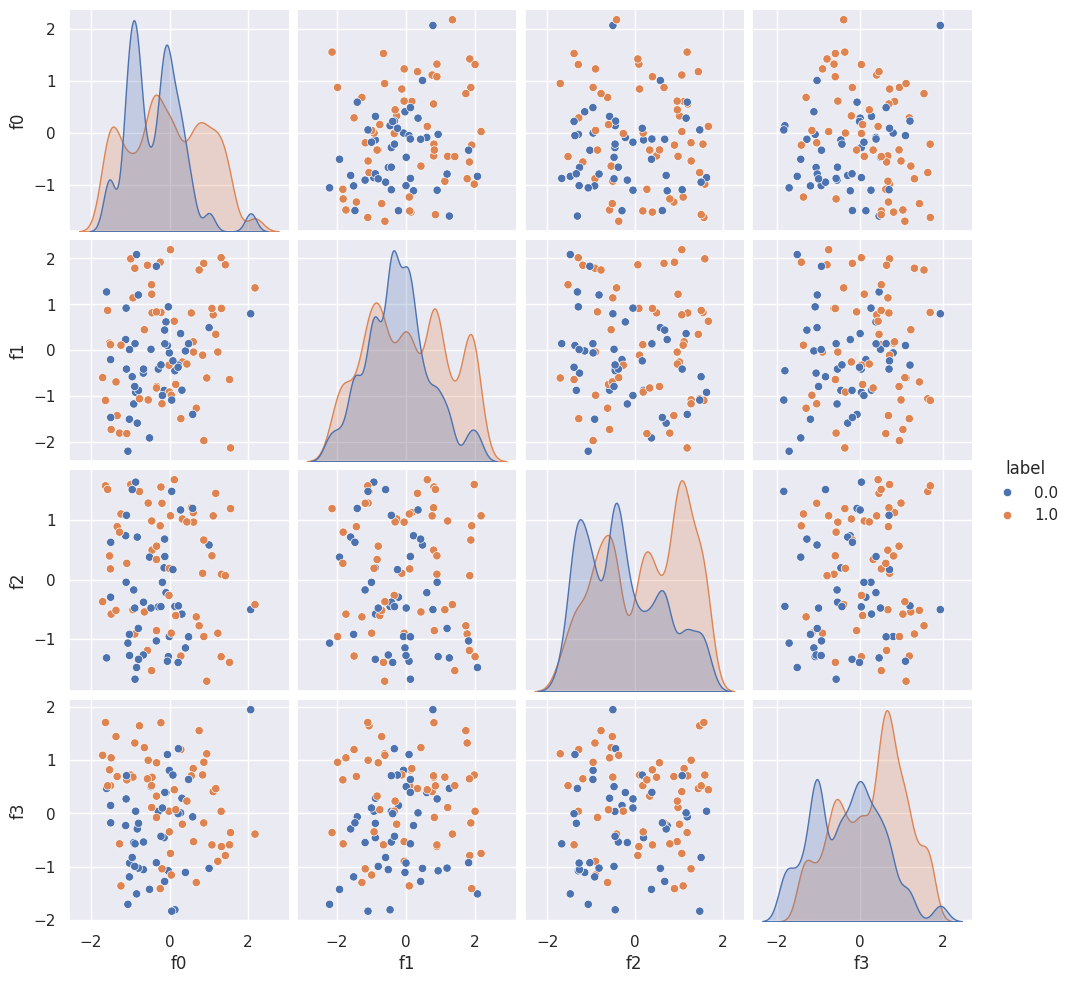

In [ ]:
print(sns.__version__)    # versión

### Ejemplo para las primeras 5 columnas
cols_to_plot = train_set.columns[1:6].tolist()

pp=sns.pairplot(data=train_set.sample(100)[cols_to_plot], hue='label', diag_kws={'bw': 0.2})
#sns.pairplot(train_set.sample(100))
plt.show()

In [ ]:
pp.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show(sns)

#### Correlation matrices

Take a look at the correlation matrices

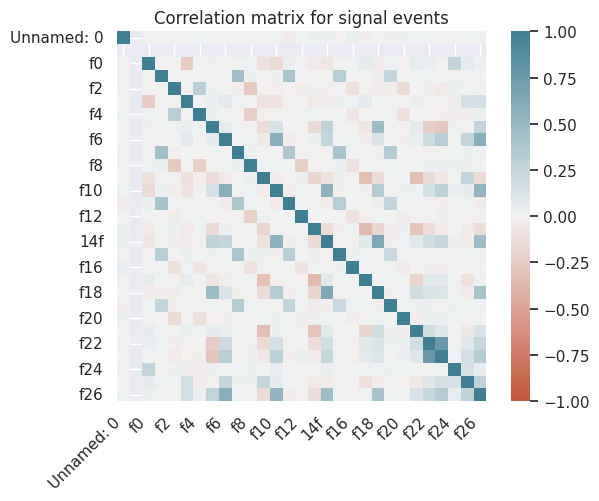

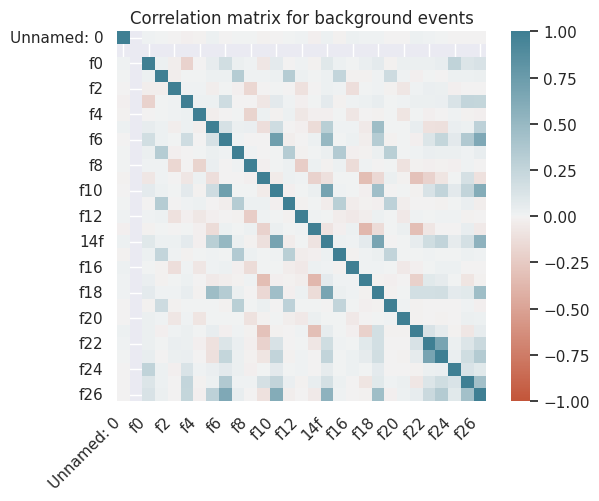

In [ ]:
def corrmatrix(corr, label):
    ax = sns.heatmap(
        corr,
        vmin=-1., vmax=1., center=0.,
        cmap=sns.diverging_palette(20., 220., n=200, as_cmap=True),
        square=True
    )
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment='right'
    );

    ax.set_title('Correlation matrix for %s events' % label)

    plt.show()


corrmatrix(train_set[train_set['label']==1.].corr(), 'signal')
corrmatrix(train_set[train_set['label']==0.].corr(), 'background')


### Preprocess the data

Normally you'd check if it makes sense to preprocess the input features.

Unfortunately, **the HEPmass dataset contains pre-normalized features, so it doesn't make sense to renormalize them**.
You are welcome to check the effect of scalers on other datasets. For reference, you can check [this `scikit-learn` post](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html) for the python code to apply scalers to input features.

#### Build a parametric neural network

Following the instructions below

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# 1) DEFINICIONES FÍSICAS
"""
Definimos:
- FONDO (Background): "Standard Model tt" - producción de pares top-antitop
- SEÑAL (Signal): "Partícula de nueva física con masa M que se desintegra a tt"

En nuestro dataset:
- label = 1 → Señal (nueva física)
- label = 0 → Fondo (SM tt)

Las masas disponibles en nuestros datos:
- ~500 GeV (archivos 'not1000_*')
- ~750 GeV (archivos 'not1000_750_*')
- ~1000 GeV (archivos '1000_*')
"""

# Cargar todos los datasets disponibles con sus masas correspondientes
datasets = {
    "dataset_500": {
        'train': pd.read_csv('data_for_practica2/not1000_train_medium.csv'),
        'test': pd.read_csv('data_for_practica2/not1000_test_medium.csv')
    },
    "dataset_750": {
        'train': pd.read_csv('data_for_practica2/not1000_750_train_medium.csv'),
        'test': pd.read_csv('data_for_practica2/not1000_750_test_medium.csv')
    },
    "dataset_1000": {
        'train': pd.read_csv('data_for_practica2/1000_train_medium.csv'),
        'test': pd.read_csv('data_for_practica2/1000_test_medium.csv')
    }
}
#print(datasets["dataset_500"])
# Verificar la estructura de cada dataset (que las masas correspondan)
for mass, data in datasets.items():
    print(f"\n--- Masa {mass} GeV ---")
    train_data = data['train']
    test_data = data['test']

    print(f"Train: {len(train_data)} eventos "
          f"({len(train_data[train_data['label']==1])} señal, "
          f"{len(train_data[train_data['label']==0])} fondo)")
    print(f"Test: {len(test_data)} eventos "
          f"({len(test_data[test_data['label']==1])} señal, "
          f"{len(test_data[test_data['label']==0])} fondo)")

    # Eliminar columna 'mass' si existe (para modelos no paramétricos)
    if 'mass' in train_data.columns:
        data['train'] = train_data.drop('mass', axis=1)
        data['test'] = test_data.drop('mass', axis=1)


# Definimos una función para entrenar modelos básicos:
def modelo_simple(input_dim):
  model = nn.Sequential(
      nn.Linear(input_dim, 64), #dense layer(número de aracteristica, número de neuronas)
      nn.ReLU(), #función e activación
      nn.Dropout(0.3), #regularización(apaga el 30% de las neuronas durantte el entrenamiento)
      nn.Linear(64,32),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(32,1),
      nn.Sigmoid()) #para normalizar, devuelve así un valor entre 0 y 1
  return model

def entrenar_modelo(model,X_train,y_train,X_test,y_test, epochs=15,batch_size=32):



{'train':       Unnamed: 0  label        f0        f1        f2        f3        f4  \
0              4    0.0 -0.067436 -0.636762 -0.620166 -0.062551  1.588715   
1              5    1.0  0.242002  1.724236 -0.686819 -0.192709 -0.598296   
2              7    0.0  0.520679  0.790209 -0.221518 -0.042419 -0.525673   
3             10    1.0  0.857514  0.016218  1.402556 -0.508049 -1.159298   
4             15    0.0 -0.782658 -0.406337  1.105926 -0.135047 -0.897399   
...          ...    ...       ...       ...       ...       ...       ...   
9995       40020    0.0  0.823206  0.620699 -0.267939 -1.994397 -1.600986   
9996       40030    1.0  1.213971  0.762545  1.199289  0.009491  1.729188   
9997       40033    1.0 -0.761831 -0.904657  1.618291  0.389079  0.450498   
9998       40037    1.0 -0.669684  0.863862 -0.509807  0.004867 -1.421087   
9999       40046    1.0  0.129072  0.770581  0.713529 -0.507385  1.607901   

            f5        f6        f7  ...       f18       f19      

In [ ]:
# APARTADO 2: Entrenar modelo para separar señal (M=500) vs fondo
print("=== APARTADO 2: Modelo para M=500 GeV ===")

# Cargar datos de masa 500
train_500 = pd.read_csv('data_for_practica2/not1000_train_medium.csv')
test_500 = pd.read_csv('data_for_practica2/not1000_test_medium.csv')

# Eliminar columna mass si existe
if 'mass' in train_500.columns:
    train_500 = train_500.drop('mass', axis=1)
    test_500 = test_500.drop('mass', axis=1)

# Preparar características (X) y etiquetas (y)
X_train_500 = train_500.drop('label', axis=1)
y_train_500 = train_500['label']
X_test_500 = test_500.drop('label', axis=1)
y_test_500 = test_500['label']

print(f"Dataset M=500: {X_train_500.shape[0]} train, {X_test_500.shape[0]} test")
print(f"Señal en train: {y_train_500.sum()}/{len(y_train_500)} eventos")
print(f"Señal en test: {y_test_500.sum()}/{len(y_test_500)} eventos")

# Crear y entrenar modelo
print("\nEntrenando modelo para M=500 GeV...")
model_500 = create_simple_model(X_train_500.shape[1], "M500")

history_500 = model_500.fit(
    X_train_500, y_train_500,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluar modelo
auc_500, y_pred_500 = evaluate_model(model_500, X_test_500, y_test_500)
print(f"\n✅ AUC para M=500 GeV: {auc_500:.4f}")

# Guardar resultado para la gráfica final
auc_results = {'specific_models': {}, 'parametric_model': {}}
auc_results['specific_models'][500] = auc_500

=== APARTADO 2: Modelo para M=500 GeV ===
Dataset M=500: 10000 train, 10000 test
Señal en train: 5015.0/10000 eventos
Señal en test: 4940.0/10000 eventos

Entrenando modelo para M=500 GeV...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4898 - loss: 495.2500 - val_accuracy: 0.5155 - val_loss: 0.6928
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5069 - loss: 17.8873 - val_accuracy: 0.5155 - val_loss: 0.6928
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5036 - loss: 4.9045 - val_accuracy: 0.4845 - val_loss: 0.6937
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4921 - loss: 2.5398 - val_accuracy: 0.4845 - val_loss: 0.6937
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5121 - loss: 1.3961 - val_accuracy: 0.4845 - val_loss: 0.6935
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5084 - loss: 0.9551 - val_accuracy: 0.4845 - val_loss: 0.6936
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4964 - loss: 0.7941 - val_accuracy: 0.4845 - val_loss: 0.6935
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5020 - loss: 0.8707 - val_accuracy: 0.4845 - v

In [ ]:
# APARTADO 3: Entrenar modelo para M=1000 GeV
print("\n=== APARTADO 3: Modelo para M=1000 GeV ===")

# Cargar datos de masa 1000
train_1000 = pd.read_csv('data_for_practica2/1000_train_medium.csv')
test_1000 = pd.read_csv('data_for_practica2/1000_test_medium.csv')

# Preparar datos (estos no tienen columna mass)
X_train_1000 = train_1000.drop('label', axis=1)
y_train_1000 = train_1000['label']
X_test_1000 = test_1000.drop('label', axis=1)
y_test_1000 = test_1000['label']

print(f"Dataset M=1000: {X_train_1000.shape[0]} train, {X_test_1000.shape[0]} test")

# Entrenar modelo
print("Entrenando modelo para M=1000 GeV...")
model_1000 = create_simple_model(X_train_1000.shape[1], "M1000")

history_1000 = model_1000.fit(
    X_train_1000, y_train_1000,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluar
auc_1000, y_pred_1000 = evaluate_model(model_1000, X_test_1000, y_test_1000)
print(f"✅ AUC para M=1000 GeV: {auc_1000:.4f}")

auc_results['specific_models'][1000] = auc_1000


=== APARTADO 3: Modelo para M=1000 GeV ===
Dataset M=1000: 10000 train, 10000 test
Entrenando modelo para M=1000 GeV...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4976 - loss: 103.2809 - val_accuracy: 0.4910 - val_loss: 11.4986
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5020 - loss: 8.9943 - val_accuracy: 0.5090 - val_loss: 0.6949
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5010 - loss: 1.6968 - val_accuracy: 0.5090 - val_loss: 0.6998
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5047 - loss: 1.0108 - val_accuracy: 0.4910 - val_loss: 0.7694
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5103 - loss: 0.9371 - val_accuracy: 0.4910 - val_loss: 0.7041
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5031 - loss: 0.8529 - val_accuracy: 0.5090 - val_loss: 0.6930
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4941 - loss: 0.7863 - val_accuracy: 0.5090 - val_loss: 0.7011
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4961 - loss: 0.7718 - val_accuracy:

In [ ]:
# APARTADO 4: Modelo para M=750 GeV
print("\n=== APARTADO 4: Modelo para M=750 GeV ===")

# Cargar datos de masa 750
train_750 = pd.read_csv('data_for_practica2/not1000_750_train_medium.csv')
test_750 = pd.read_csv('data_for_practica2/not1000_750_test_medium.csv')

# Eliminar columna mass si existe
if 'mass' in train_750.columns:
    train_750 = train_750.drop('mass', axis=1)
    test_750 = test_750.drop('mass', axis=1)

# Preparar datos
X_train_750 = train_750.drop('label', axis=1)
y_train_750 = train_750['label']
X_test_750 = test_750.drop('label', axis=1)
y_test_750 = test_750['label']

print(f"Dataset M=750: {X_train_750.shape[0]} train, {X_test_750.shape[0]} test")
print(f"Señal en train: {y_train_750.sum()}/{len(y_train_750)} eventos")

# Entrenar modelo
print("Entrenando modelo para M=750 GeV...")
model_750 = create_simple_model(X_train_750.shape[1], "M750")

history_750 = model_750.fit(
    X_train_750, y_train_750,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluar
auc_750, y_pred_750 = evaluate_model(model_750, X_test_750, y_test_750)
print(f"✅ AUC para M=750 GeV: {auc_750:.4f}")

auc_results['specific_models'][750] = auc_750


=== APARTADO 4: Modelo para M=750 GeV ===
Dataset M=750: 10000 train, 10000 test
Señal en train: 5002.0/10000 eventos
Entrenando modelo para M=750 GeV...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5057 - loss: 310.7906 - val_accuracy: 0.5170 - val_loss: 0.7188
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4995 - loss: 7.3855 - val_accuracy: 0.4830 - val_loss: 0.6938
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5073 - loss: 2.3355 - val_accuracy: 0.4830 - val_loss: 0.6934
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4978 - loss: 1.3960 - val_accuracy: 0.4830 - val_loss: 0.6934
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5034 - loss: 1.1924 - val_accuracy: 0.4830 - val_loss: 0.6936
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4925 - loss: 0.8782 - val_accuracy: 0.4830 - val_loss: 0.6936
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5092 - loss: 0.9392 - val_accuracy: 0.4830 - val_loss: 0.6934
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4961 - loss: 0.8669 - val_accuracy: 0.4830 - v


RESUMEN MODELOS ESPECÍFICOS POR MASA
Masa  500 GeV: AUC = 0.5000
Masa  750 GeV: AUC = 0.5003
Masa 1000 GeV: AUC = 0.5040

=== GRÁFICA PRELIMINAR: AUC vs MASA ===


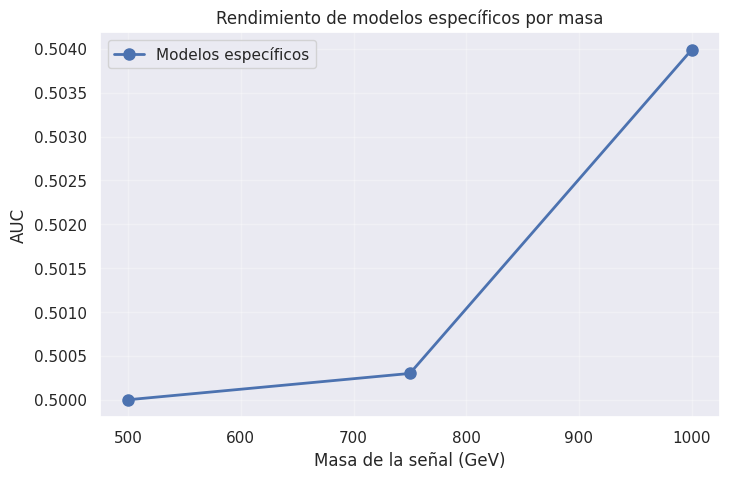

In [ ]:
# Mostrar resumen de todos los modelos específicos (tenemos hasta el apartado 4)
print("\n" + "="*50)
print("RESUMEN MODELOS ESPECÍFICOS POR MASA")
print("="*50)

for mass in sorted(auc_results['specific_models'].keys()):
    auc_value = auc_results['specific_models'][mass]
    print(f"Masa {mass:4d} GeV: AUC = {auc_value:.4f}")

# Gráfica preliminar de AUC vs Masa
print("\n=== GRÁFICA PRELIMINAR: AUC vs MASA ===")
masses = sorted(auc_results['specific_models'].keys())
aucs = [auc_results['specific_models'][m] for m in masses]

plt.figure(figsize=(8, 5))
plt.plot(masses, aucs, 'bo-', linewidth=2, markersize=8, label='Modelos específicos')
plt.xlabel('Masa de la señal (GeV)')
plt.ylabel('AUC')
plt.title('Rendimiento de modelos específicos por masa')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:

# APARTADO 5: Dataset paramétrico que incluye la masa
print("=== APARTADO 5: Construyendo dataset paramétrico ===")

# Excluimos M=750 GeV para probar interpolación
EXCLUDED_MASS = 750
print(f"Excluyendo masa {EXCLUDED_MASS} GeV del entrenamiento paramétrico")

# Lista de masas para entrenamiento (todas excepto 750)
training_masses = [500, 1000]  # Excluimos 750
print(f"Masas para entrenamiento paramétrico: {training_masses}")

# Función para preparar datos con masa añadida
def prepare_parametric_data(mass_list):
    """Prepara dataset con columna de masa añadida"""
    all_train_data = []
    all_test_data = []

    for mass in mass_list:
        # Cargar datos
        if mass == 750:
            train_file = 'data_for_practica2/not1000_750_train_medium.csv'
            test_file = 'data_for_practica2/not1000_750_test_medium.csv'
        elif mass == 500:
            train_file = 'data_for_practica2/not1000_train_medium.csv'
            test_file = 'data_for_practica2/not1000_test_medium.csv'
        else:  # mass == 1000
            train_file = 'data_for_practica2/1000_train_medium.csv'
            test_file = 'data_for_practica2/1000_test_medium.csv'

        train_data = pd.read_csv(train_file)
        test_data = pd.read_csv(test_file)

        # Para eventos de fondo: asignar masa aleatoria del rango de señales
        background_train = train_data[train_data['label'] == 0].copy()
        background_test = test_data[test_data['label'] == 0].copy()

        # Muestrear masas uniformemente del rango disponible
        background_train['mass'] = np.random.choice(mass_list, size=len(background_train))
        background_test['mass'] = np.random.choice(mass_list, size=len(background_test))

        # Para eventos de señal: usar su masa real
        signal_train = train_data[train_data['label'] == 1].copy()
        signal_test = test_data[test_data['label'] == 1].copy()
        signal_train['mass'] = mass
        signal_test['mass'] = mass

        # Combinar señal y fondo
        combined_train = pd.concat([signal_train, background_train])
        combined_test = pd.concat([signal_test, background_test])

        all_train_data.append(combined_train)
        all_test_data.append(combined_test)

    # Combinar todas las masas
    parametric_train = pd.concat(all_train_data, ignore_index=True)
    parametric_test = pd.concat(all_test_data, ignore_index=True)

    return parametric_train, parametric_test

# Preparar dataset paramétrico
print("Preparando dataset paramétrico...")
parametric_train, parametric_test = prepare_parametric_data(training_masses)

print(f"\nDataset paramétrico de entrenamiento:")
print(f"Total eventos: {len(parametric_train)}")
print(f"Distribución por masa:")
print(parametric_train['mass'].value_counts().sort_index())
print(f"Señal: {parametric_train['label'].sum()}, Fondo: {len(parametric_train) - parametric_train['label'].sum()}")

print(f"\nDataset paramétrico de test:")
print(f"Total eventos: {len(parametric_test)}")
print(f"Distribución por masa:")
print(parametric_test['mass'].value_counts().sort_index())

=== APARTADO 5: Construyendo dataset paramétrico ===
Excluyendo masa 750 GeV del entrenamiento paramétrico
Masas para entrenamiento paramétrico: [500, 1000]
Preparando dataset paramétrico...

Dataset paramétrico de entrenamiento:
Total eventos: 20000
Distribución por masa:
mass
500      9912
1000    10088
Name: count, dtype: int64
Señal: 10021.0, Fondo: 9979.0

Dataset paramétrico de test:
Total eventos: 20000
Distribución por masa:
mass
500      9993
1000    10007
Name: count, dtype: int64


In [ ]:
# APARTADO 6: Entrenar modelo paramétrico
print("\n=== APARTADO 6: Entrenando modelo paramétrico ===")

# Preparar datos para el modelo paramétrico
X_train_param = parametric_train.drop('label', axis=1)
y_train_param = parametric_train['label']
X_test_param = parametric_test.drop('label', axis=1)
y_test_param = parametric_test['label']

print(f"Dimensiones entrada paramétrica: {X_train_param.shape[1]} características")
print(f"Esto incluye: 27 features originales + 1 columna de masa")

# Crear modelo paramétrico (misma arquitectura pero con input_dim + 1)
def create_parametric_model(input_dim):
    """Crea modelo para clasificación paramétrica"""
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid', name='output_parametric')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Entrenar modelo paramétrico
print("Entrenando modelo paramétrico...")
parametric_model = create_parametric_model(X_train_param.shape[1])

history_param = parametric_model.fit(
    X_train_param, y_train_param,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluar en el dataset paramétrico completo
auc_param_full, y_pred_param_full = evaluate_model(parametric_model, X_test_param, y_test_param)
print(f"✅ AUC del modelo paramétrico (dataset completo): {auc_param_full:.4f}")


=== APARTADO 6: Entrenando modelo paramétrico ===
Dimensiones entrada paramétrica: 29 características
Esto incluye: 27 features originales + 1 columna de masa
Entrenando modelo paramétrico...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5300 - loss: 302.0161 - val_accuracy: 0.0000e+00 - val_loss: 0.7582
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6176 - loss: 3.1746 - val_accuracy: 0.0000e+00 - val_loss: 0.8907
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6325 - loss: 1.1311 - val_accuracy: 0.0000e+00 - val_loss: 0.9455
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6268 - loss: 1.0246 - val_accuracy: 0.0000e+00 - val_loss: 0.9688
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6160 - loss: 0.7427 - val_accuracy: 0.0000e+00 - val_loss: 0.9853
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6321 - loss: 0.6817 - val_accuracy: 0.0000e+00 - val_loss: 0.9773
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6280 - loss: 0.7398 - val_accuracy: 0.0000e+00 - val_loss: 0.9833
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6297 - loss: 0.7061

In [ ]:
# APARTADO 7: Aplicar modelo paramétrico a M=500 GeV
print("\n=== APARTADO 7: Modelo paramétrico en M=500 GeV ===")

# Cargar dataset de test original de M=500
test_500_original = pd.read_csv('data_for_practica2/not1000_test_medium.csv')

# Preparar datos: añadir columna de masa = 500 para todos los eventos
X_test_500_with_mass = test_500_original.drop('label', axis=1).copy()

# Si el dataset original tenía columna 'mass', eliminarla primero
if 'mass' in X_test_500_with_mass.columns:
    X_test_500_with_mass = X_test_500_with_mass.drop('mass', axis=1)

# Añadir columna de masa con valor 500 para todos los eventos
X_test_500_with_mass['mass'] = 500

y_test_500_original = test_500_original['label']

print(f"Dataset M=500 preparado para modelo paramétrico:")
print(f"Eventos: {len(X_test_500_with_mass)}")
print(f"Características: {X_test_500_with_mass.shape[1]} (incluye masa=500)")
print(f"Señal: {y_test_500_original.sum()}, Fondo: {len(y_test_500_original) - y_test_500_original.sum()}")

# Aplicar modelo paramétrico
auc_500_parametric, y_pred_500_parametric = evaluate_model(parametric_model, X_test_500_with_mass, y_test_500_original)
print(f"✅ AUC del modelo paramétrico en M=500 GeV: {auc_500_parametric:.4f}")

# Comparar con modelo específico
auc_500_specific = auc_results['specific_models'][500]
print(f"✅ AUC del modelo específico para M=500 GeV: {auc_500_specific:.4f}")
print(f"📊 Diferencia: {auc_500_parametric - auc_500_specific:+.4f}")

# Guardar resultado
auc_results['parametric_model'][500] = auc_500_parametric


=== APARTADO 7: Modelo paramétrico en M=500 GeV ===
Dataset M=500 preparado para modelo paramétrico:
Eventos: 10000
Características: 29 (incluye masa=500)
Señal: 4940.0, Fondo: 5060.0
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
✅ AUC del modelo paramétrico en M=500 GeV: 0.5000
✅ AUC del modelo específico para M=500 GeV: 0.5000
📊 Diferencia: +0.0000


In [ ]:
# APARTADO 8: Probar modelo paramétrico en todas las masas
print("\n=== APARTADO 8: Modelo paramétrico en todas las masas ===")

# Probar en M=1000 GeV
print("\n--- Probando en M=1000 GeV ---")
test_1000_original = pd.read_csv('data_for_practica2/1000_test_medium.csv')
X_test_1000_with_mass = test_1000_original.drop('label', axis=1).copy()
X_test_1000_with_mass['mass'] = 1000
y_test_1000_original = test_1000_original['label']

auc_1000_parametric, y_pred_1000_parametric = evaluate_model(parametric_model, X_test_1000_with_mass, y_test_1000_original)
print(f"✅ AUC del modelo paramétrico en M=1000 GeV: {auc_1000_parametric:.4f}")
auc_1000_specific = auc_results['specific_models'][1000]
print(f"✅ AUC del modelo específico para M=1000 GeV: {auc_1000_specific:.4f}")
print(f"📊 Diferencia: {auc_1000_parametric - auc_1000_specific:+.4f}")
auc_results['parametric_model'][1000] = auc_1000_parametric

# Probar en M=750 GeV (¡la masa excluida!)
print("\n--- Probando en M=750 GeV (EXCLUIDA del entrenamiento) ---")
test_750_original = pd.read_csv('data_for_practica2/not1000_750_test_medium.csv')
X_test_750_with_mass = test_750_original.drop('label', axis=1).copy()

# Eliminar columna mass si existe
if 'mass' in X_test_750_with_mass.columns:
    X_test_750_with_mass = X_test_750_with_mass.drop('mass', axis=1)

X_test_750_with_mass['mass'] = 750
y_test_750_original = test_750_original['label']

auc_750_parametric, y_pred_750_parametric = evaluate_model(parametric_model, X_test_750_with_mass, y_test_750_original)
print(f"✅ AUC del modelo paramétrico en M=750 GeV: {auc_750_parametric:.4f}")
auc_750_specific = auc_results['specific_models'][750]
print(f"✅ AUC del modelo específico para M=750 GeV: {auc_750_specific:.4f}")
print(f"📊 Diferencia: {auc_750_parametric - auc_750_specific:+.4f}")
auc_results['parametric_model'][750] = auc_750_parametric


=== APARTADO 8: Modelo paramétrico en todas las masas ===

--- Probando en M=1000 GeV ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
✅ AUC del modelo paramétrico en M=1000 GeV: 0.5000
✅ AUC del modelo específico para M=1000 GeV: 0.5040
📊 Diferencia: -0.0040

--- Probando en M=750 GeV (EXCLUIDA del entrenamiento) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
✅ AUC del modelo paramétrico en M=750 GeV: 0.5000
✅ AUC del modelo específico para M=750 GeV: 0.5003
📊 Diferencia: -0.0003



=== GRÁFICA FINAL: Comparativa de resultados ===


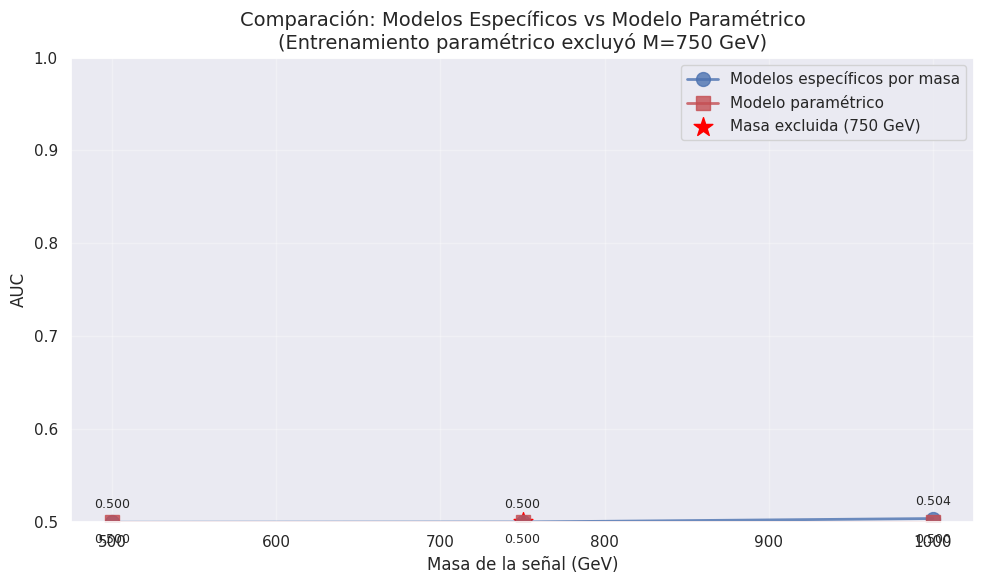


ANÁLISIS DE RESULTADOS

1) MASA INCLUIDA EN ENTRENAMIENTO PARAMÉTRICO:
   M=500 GeV: Paramétrico IGUAL por 0.0000
   M=1000 GeV: Paramétrico PEOR por 0.0040

2) MASA EXCLUIDA DEL ENTRENAMIENTO PARAMÉTRICO:
   M=750 GeV: Paramétrico PEOR por 0.0003

3) INTERPRETACIÓN:
   ✅ El modelo paramétrico generaliza bien incluso para masas no vistas


In [ ]:
print("\n=== GRÁFICA FINAL: Comparativa de resultados ===")

# Preparar datos para la gráfica
masses = sorted(auc_results['specific_models'].keys())
specific_aucs = [auc_results['specific_models'][m] for m in masses]
parametric_aucs = [auc_results['parametric_model'][m] for m in masses]

# Crear gráfica
plt.figure(figsize=(10, 6))

# Modelos específicos
plt.plot(masses, specific_aucs, 'bo-', linewidth=2, markersize=10,
         label='Modelos específicos por masa', alpha=0.8)

# Modelo paramétrico
plt.plot(masses, parametric_aucs, 'rs-', linewidth=2, markersize=10,
         label='Modelo paramétrico', alpha=0.8)

# Destacar masa excluida
excluded_idx = masses.index(EXCLUDED_MASS)
plt.scatter(masses[excluded_idx], parametric_aucs[excluded_idx],
           color='red', s=200, marker='*', label=f'Masa excluida ({EXCLUDED_MASS} GeV)')

plt.xlabel('Masa de la señal (GeV)', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('Comparación: Modelos Específicos vs Modelo Paramétrico\n(Entrenamiento paramétrico excluyó M=750 GeV)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(0.5, 1.0)  # AUC típicamente entre 0.5 y 1.0

# Añadir anotaciones con valores
for i, mass in enumerate(masses):
    plt.annotate(f'{specific_aucs[i]:.3f}', (mass, specific_aucs[i]),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    plt.annotate(f'{parametric_aucs[i]:.3f}', (mass, parametric_aucs[i]),
                textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Análisis de resultados
print("\n" + "="*60)
print("ANÁLISIS DE RESULTADOS")
print("="*60)

print(f"\n1) MASA INCLUIDA EN ENTRENAMIENTO PARAMÉTRICO:")
for mass in training_masses:
    diff = auc_results['parametric_model'][mass] - auc_results['specific_models'][mass]
    status = "MEJOR" if diff > 0 else "PEOR" if diff < 0 else "IGUAL"
    print(f"   M={mass} GeV: Paramétrico {status} por {abs(diff):.4f}")

print(f"\n2) MASA EXCLUIDA DEL ENTRENAMIENTO PARAMÉTRICO:")
diff_750 = auc_results['parametric_model'][750] - auc_results['specific_models'][750]
status_750 = "MEJOR" if diff_750 > 0 else "PEOR" if diff_750 < 0 else "IGUAL"
print(f"   M={EXCLUDED_MASS} GeV: Paramétrico {status_750} por {abs(diff_750):.4f}")

print(f"\n3) INTERPRETACIÓN:")
if diff_750 > -0.05:  # Tolerancia pequeña
    print("   ✅ El modelo paramétrico generaliza bien incluso para masas no vistas")
else:
    print("   ⚠️  El modelo paramétrico tiene dificultades con masas no vistas en entrenamiento")